In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
data = load_diabetes()
df_X = data.data
df_y = data.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


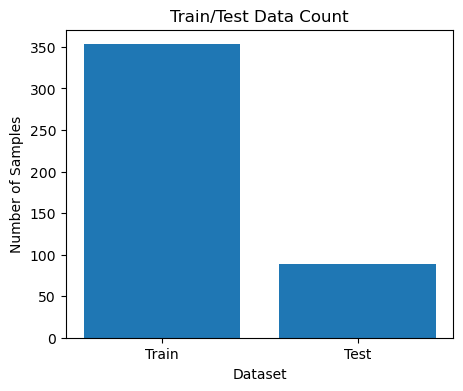

In [17]:
plt.figure(figsize = (5,4))
plt.bar( 
    ["Train","Test"],[len(y_train),len(y_test)]
       )

plt.title("Train/Test Data Count")
plt.xlabel("Dataset")
plt.ylabel("Number of Samples")

plt.show()

In [18]:
X = np.array(df_X)
y = np.array(df_y)

print(type(X), X.dtype)
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64


In [19]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [20]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [21]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  
    return mse

In [22]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [23]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [29]:
LEARNING_RATE = 0.1

In [31]:
global W, b

losses = []

for i in range(1, 2001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 3327.0344
Iteration 200 : Loss 3283.3126
Iteration 300 : Loss 3245.2230
Iteration 400 : Loss 3211.7710
Iteration 500 : Loss 3182.1940
Iteration 600 : Loss 3155.8977
Iteration 700 : Loss 3132.4118
Iteration 800 : Loss 3111.3580
Iteration 900 : Loss 3092.4269
Iteration 1000 : Loss 3075.3620
Iteration 1100 : Loss 3059.9477
Iteration 1200 : Loss 3046.0004
Iteration 1300 : Loss 3033.3622
Iteration 1400 : Loss 3021.8961
Iteration 1500 : Loss 3011.4821
Iteration 1600 : Loss 3002.0148
Iteration 1700 : Loss 2993.4007
Iteration 1800 : Loss 2985.5569
Iteration 1900 : Loss 2978.4091
Iteration 2000 : Loss 2971.8913


In [32]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2868.78448801915)

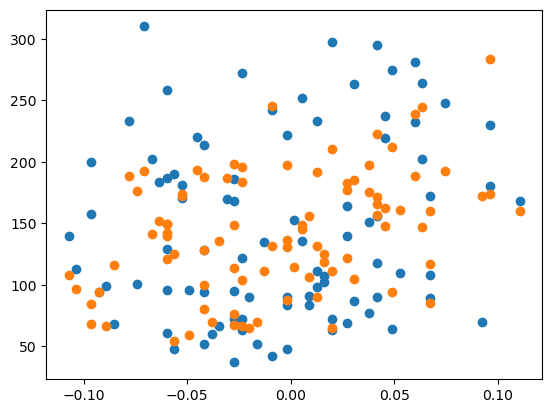

In [33]:
plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()